RITHESH P 24BAD098


In [1]:
# ============================================
# EXPERIMENT 6
# IMPLEMENTATION OF LSTM FOR SENTIMENT ANALYSIS
# Using IMDB Dataset.csv
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import string

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow Version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow Version: 2.20.0
Libraries imported successfully!


In [2]:
# ============================================
# LOAD DATASET
# ============================================

from google.colab import files

uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [3]:
# Read the uploaded CSV file

df = pd.read_csv("IMDB Dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Dataset shape: (50000, 2)

Column names:
Index(['review', 'sentiment'], dtype='object')

First 5 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
# ============================================
# DATASET EXPLORATION
# ============================================

print("Number of reviews:", len(df))

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

Number of reviews: 50000

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Missing values:
review       0
sentiment    0
dtype: int64


In [5]:
# ============================================
# DATA CLEANING
# ============================================

# Remove missing values
df = df.dropna()

# Remove duplicate reviews
df = df.drop_duplicates()

print("Dataset shape after cleaning:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape after cleaning: (49582, 2)

Missing values:
review       0
sentiment    0
dtype: int64


In [6]:
# ============================================
# SAMPLE REVIEWS
# ============================================

print("POSITIVE REVIEW:")
print(df[df["sentiment"] == "positive"]["review"].iloc[0])

print("\n============================================\n")

print("NEGATIVE REVIEW:")
print(df[df["sentiment"] == "negative"]["review"].iloc[0])

POSITIVE REVIEW:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

In [7]:
# ============================================
# TEXT PREPROCESSING
# ============================================

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<br\s*/?>', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


df["clean_review"] = df["review"].apply(clean_text)

print("Original review:")
print(df["review"].iloc[0])

print("\nCleaned review:")
print(df["clean_review"].iloc[0])

Original review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

In [8]:
# ============================================
# LABEL ENCODING
# ============================================

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["sentiment"])

print(df[["sentiment", "label"]].head(10))

print("\nLabel mapping:")
print("Negative = 0")
print("Positive = 1")

  sentiment  label
0  positive      1
1  positive      1
2  positive      1
3  negative      0
4  positive      1
5  positive      1
6  positive      1
7  negative      0
8  negative      0
9  positive      1

Label mapping:
Negative = 0
Positive = 1


In [9]:
# ============================================
# INPUT AND OUTPUT
# ============================================

X = df["clean_review"].values
y = df["label"].values

print("Number of reviews:", len(X))
print("Number of labels:", len(y))

Number of reviews: 49582
Number of labels: 49582


In [10]:
# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 39665
Testing samples: 9917


In [11]:
# ============================================
# TOKENIZATION
# ============================================

VOCAB_SIZE = 10000
MAX_LENGTH = 200

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

# Build vocabulary using training reviews
tokenizer.fit_on_texts(X_train)

print("Vocabulary created successfully!")
print("Total words found:", len(tokenizer.word_index))
print("Words used:", VOCAB_SIZE)

Vocabulary created successfully!
Total words found: 143091
Words used: 10000


In [12]:
# ============================================
# TEXT TO NUMERICAL SEQUENCES
# ============================================

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

print("Original review:")
print(X_train[0])

print("\nNumerical sequence:")
print(X_train_sequences[0])

Original review:
i am one of jehovahs witnesses and i also work in an acute care medical facility over the years i have seen people die from hemolytic reactions to blood transfusions have attended numerous conferences on blood born pathogens and have seen several patients become seriously ill from pathogens induced by transfused blood i have also heard several jehovahs witnesses being told that they will die if they refuse blood and after years in the field i have never actually seen it happen leaving the question is it really unreasonable to refuse blood transfusions or is the community at large benefiting from the battle on this issue the issue for jehovahs witnesses is a moral one you must abstain from blood is not an ambiguous statement thank you for this movie and allowing comments on it

Numerical sequence:
[10, 229, 28, 5, 1, 4905, 3, 10, 81, 161, 8, 33, 1, 446, 2721, 7710, 129, 2, 151, 10, 25, 105, 83, 763, 35, 1, 3720, 6, 545, 1, 25, 6356, 1838, 1, 20, 545, 1450, 1, 3, 25, 105

In [13]:
# ============================================
# SEQUENCE PADDING
# ============================================

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Training data shape:", X_train_padded.shape)
print("Testing data shape:", X_test_padded.shape)

print("\nFirst padded sequence:")
print(X_train_padded[0])

Training data shape: (39665, 200)
Testing data shape: (9917, 200)

First padded sequence:
[  10  229   28    5    1 4905    3   10   81  161    8   33    1  446
 2721 7710  129    2  151   10   25  105   83  763   35    1 3720    6
  545    1   25 6356 1838    1   20  545 1450    1    3   25  105  429
 4458  414  600  528   35    1    1   32    1  545   10   25   81  535
  429    1 4905  106  550   12   34   76  763   43   34 5779  545    3
  101  151    8    2 1855   10   25  109  156  105    9  562 1174    2
  882    7    9   62    1    6 5779  545    1   39    7    2 1858   30
 1012    1   35    2  907   20   11 1751    2 1751   15    1 4905    7
    4 1477   28   22  213    1   35  545    7   21   33 5366 2509 1359
   22   15   11   17    3 3428  757   20    9    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0   

In [14]:
# ============================================
# TRAINING AND VALIDATION DATA
# ============================================

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_padded,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training data:", X_train_final.shape)
print("Validation data:", X_val.shape)
print("Testing data:", X_test_padded.shape)

Training data: (31732, 200)
Validation data: (7933, 200)
Testing data: (9917, 200)


In [15]:
# ============================================
# PART B: EMBEDDING GENERATION
# ============================================

EMBEDDING_DIM = 128

embedding_layer = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM
)

# Generate embedding for one sample
sample_input = tf.constant(X_train_padded[:1])

sample_embedding = embedding_layer(sample_input)

print("Vocabulary Size:", VOCAB_SIZE)
print("Embedding Dimension:", EMBEDDING_DIM)

print("\nEmbedding representation shape:")
print(sample_embedding.shape)

Vocabulary Size: 10000
Embedding Dimension: 128

Embedding representation shape:
(1, 200, 128)


In [16]:
# ============================================
# PART C: BUILD LSTM MODEL
# ============================================

model = Sequential([

    # Embedding layer
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    # LSTM layer
    LSTM(128),

    # Dropout layer
    Dropout(0.5),

    # Output layer
    Dense(1, activation="sigmoid")
])

# Compile model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
# ============================================
# MODEL TRAINING
# ============================================

EPOCHS = 5
BATCH_SIZE = 128

history = model.fit(
    X_train_final,
    y_train_final,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/5
248/248 ━━━━━━━━━━━━━━━━━━━━ 201s 801ms/step - accuracy: 0.5242 - loss: 0.6920 - val_accuracy: 0.5327 - val_loss: 0.6883
Epoch 2/5
248/248 ━━━━━━━━━━━━━━━━━━━━ 201s 798ms/step - accuracy: 0.5863 - loss: 0.6615 - val_accuracy: 0.6037 - val_loss: 0.6501
Epoch 3/5
248/248 ━━━━━━━━━━━━━━━━━━━━ 197s 795ms/step - accuracy: 0.6198 - loss: 0.6290 - val_accuracy: 0.6571 - val_loss: 0.6249
Epoch 4/5
248/248 ━━━━━━━━━━━━━━━━━━━━ 203s 816ms/step - accuracy: 0.7568 - loss: 0.5128 - val_accuracy: 0.8079 - val_loss: 0.4611
Epoch 5/5
248/248 ━━━━━━━━━━━━━━━━━━━━ 196s 791ms/step - accuracy: 0.8566 - loss: 0.3681 - val_accuracy: 0.8365 - val_loss: 0.4066


In [18]:
# ============================================
# TRAINING RESULTS
# ============================================

print("Training Accuracy:")
print(history.history["accuracy"])

print("\nValidation Accuracy:")
print(history.history["val_accuracy"])

print("\nTraining Loss:")
print(history.history["loss"])

print("\nValidation Loss:")
print(history.history["val_loss"])

Training Accuracy:
[0.5241711735725403, 0.5862536430358887, 0.6198474764823914, 0.7568385004997253, 0.8565801382064819]

Validation Accuracy:
[0.5327114462852478, 0.6036808490753174, 0.6571284532546997, 0.8078910708427429, 0.8365057110786438]

Training Loss:
[0.6919760704040527, 0.6614670753479004, 0.6290196180343628, 0.5127936005592346, 0.3681350350379944]

Validation Loss:
[0.6883333325386047, 0.6500759720802307, 0.6249094605445862, 0.4610530436038971, 0.4065667688846588]


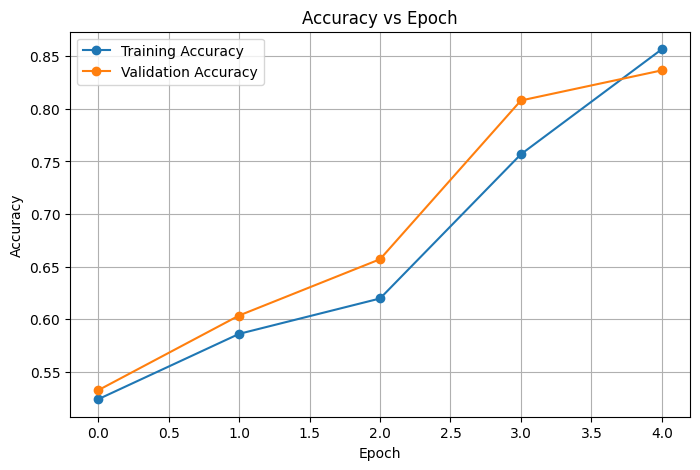

In [19]:
# ============================================
# ACCURACY VS EPOCH
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

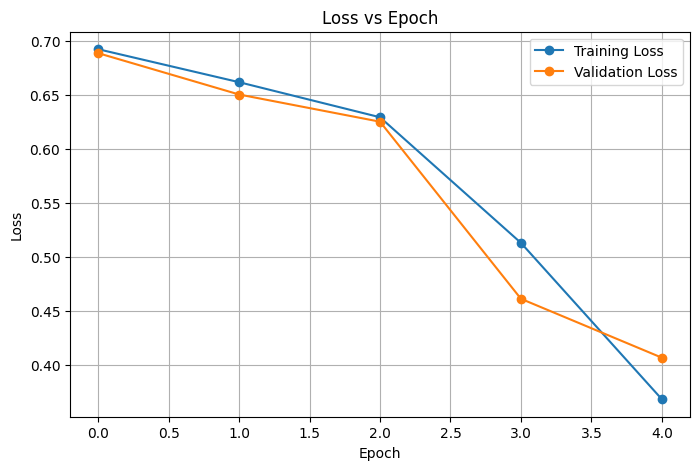

In [20]:
# ============================================
# LOSS VS EPOCH
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
# ============================================
# TEST DATA EVALUATION
# ============================================

test_loss, test_accuracy = model.evaluate(
    X_test_padded,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.402312695980072
Test Accuracy: 0.8365433216094971


In [22]:
# ============================================
# SENTIMENT PREDICTIONS
# ============================================

prediction_probabilities = model.predict(
    X_test_padded,
    verbose=0
)

# Convert probabilities into 0 or 1
predictions = (
    prediction_probabilities >= 0.5
).astype(int).flatten()

print("First 20 predicted labels:")
print(predictions[:20])

print("\nFirst 20 actual labels:")
print(y_test[:20])

First 20 predicted labels:
[0 1 1 0 0 1 0 0 1 0 0 1 1 0 1 0 1 0 1 0]

First 20 actual labels:
[0 1 1 0 0 1 0 0 1 0 0 1 1 0 1 1 1 0 1 0]


In [23]:
# ============================================
# EVALUATION METRICS
# ============================================

accuracy = accuracy_score(
    y_test,
    predictions
)

precision = precision_score(
    y_test,
    predictions
)

recall = recall_score(
    y_test,
    predictions
)

f1 = f1_score(
    y_test,
    predictions
)

print("======================================")
print("LSTM MODEL PERFORMANCE")
print("======================================")

print("Accuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1-Score  :", round(f1, 4))

LSTM MODEL PERFORMANCE
Accuracy  : 0.8365
Precision : 0.8191
Recall    : 0.8654
F1-Score  : 0.8416


Confusion Matrix:
[[3989  951]
 [ 670 4307]]


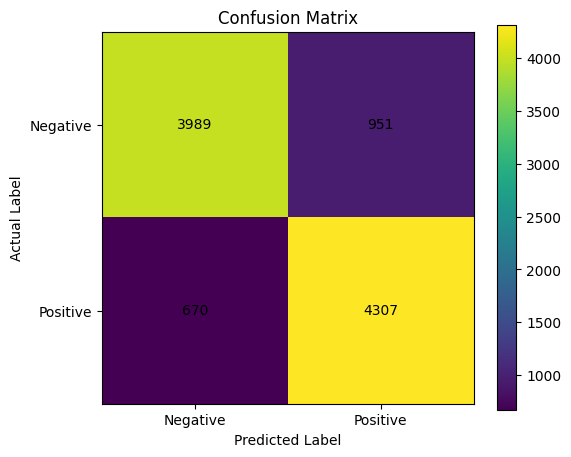

In [24]:
# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    predictions
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Negative", "Positive"]
)

plt.yticks(
    [0, 1],
    ["Negative", "Positive"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

In [25]:
# ============================================
# CLASSIFICATION REPORT
# ============================================

print(
    classification_report(
        y_test,
        predictions,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.86      0.81      0.83      4940
    Positive       0.82      0.87      0.84      4977

    accuracy                           0.84      9917
   macro avg       0.84      0.84      0.84      9917
weighted avg       0.84      0.84      0.84      9917



In [26]:
# ============================================
# CUSTOM SENTIMENT PREDICTION
# ============================================

def predict_sentiment(review):

    # Clean review
    cleaned_review = clean_text(review)

    # Convert text to sequence
    sequence = tokenizer.texts_to_sequences(
        [cleaned_review]
    )

    # Pad sequence
    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    # Predict
    probability = model.predict(
        padded_sequence,
        verbose=0
    )[0][0]

    if probability >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("Review:")
    print(review)

    print("\nPredicted Sentiment:")
    print(sentiment)

    print("\nPositive Probability:")
    print(round(float(probability), 4))

In [27]:
# ============================================
# TEST SAMPLE REVIEWS
# ============================================

predict_sentiment(
    "This movie was absolutely amazing and I loved every minute of it."
)

print("\n========================================\n")

predict_sentiment(
    "This movie was boring, terrible and a complete waste of time."
)

Review:
This movie was absolutely amazing and I loved every minute of it.

Predicted Sentiment:
Positive

Positive Probability:
0.9076


Review:
This movie was boring, terrible and a complete waste of time.

Predicted Sentiment:
Negative

Positive Probability:
0.0735


In [28]:
# ============================================
# MULTIPLE SAMPLE REVIEWS
# ============================================

sample_reviews = [

    "The movie was excellent and fantastic.",

    "I really enjoyed this movie and the acting was wonderful.",

    "The movie was boring and disappointing.",

    "This was one of the worst movies I have ever watched.",

    "Amazing story with excellent performances."
]

for review in sample_reviews:

    predict_sentiment(review)

    print("----------------------------------------")

Review:
The movie was excellent and fantastic.

Predicted Sentiment:
Positive

Positive Probability:
0.9001
----------------------------------------
Review:
I really enjoyed this movie and the acting was wonderful.

Predicted Sentiment:
Positive

Positive Probability:
0.8408
----------------------------------------
Review:
The movie was boring and disappointing.

Predicted Sentiment:
Negative

Positive Probability:
0.3675
----------------------------------------
Review:
This was one of the worst movies I have ever watched.

Predicted Sentiment:
Negative

Positive Probability:
0.142
----------------------------------------
Review:
Amazing story with excellent performances.

Predicted Sentiment:
Positive

Positive Probability:
0.9272
----------------------------------------


In [29]:
# ============================================
# FINAL RESULT
# ============================================

print("============================================")
print("LSTM SENTIMENT ANALYSIS")
print("FINAL RESULTS")
print("============================================")

print("Dataset              : IMDB Dataset")
print("Total Reviews        :", len(df))
print("Vocabulary Size      :", VOCAB_SIZE)
print("Maximum Sequence     :", MAX_LENGTH)
print("Embedding Dimension  :", EMBEDDING_DIM)
print("LSTM Units           : 128")
print("Epochs               :", EPOCHS)

print("\n--------------------------------------------")

print("Test Accuracy :", round(test_accuracy, 4))
print("Precision     :", round(precision, 4))
print("Recall        :", round(recall, 4))
print("F1-Score      :", round(f1, 4))

print("\n--------------------------------------------")
print("Experiment completed successfully!")

LSTM SENTIMENT ANALYSIS
FINAL RESULTS
Dataset              : IMDB Dataset
Total Reviews        : 49582
Vocabulary Size      : 10000
Maximum Sequence     : 200
Embedding Dimension  : 128
LSTM Units           : 128
Epochs               : 5

--------------------------------------------
Test Accuracy : 0.8365
Precision     : 0.8191
Recall        : 0.8654
F1-Score      : 0.8416

--------------------------------------------
Experiment completed successfully!
